## Ejercicio de Regresión 1 (Core)
#####  Aplicar los conceptos de regresión lineal para resolver un problema práctico utilizando Python.

##### Descripción del problema: Supongamos que trabajas en una empresa que desea predecir el precio de venta de casas en función de varias características. Tienes un conjunto de datos con información sobre las casas, incluyendo el tamaño de la casa (en pies cuadrados), el número de habitaciones, el número de baños y la antigüedad de la casa (en años). Tu tarea es construir un modelo de regresión lineal que pueda predecir el precio de venta de una casa dada.

##### 1.- Carga de datos: Descarga el archivo de datos house_prices.csv que contiene las siguientes columnas:
#####   1.1.-   SqFt: Tamaño de la casa en pies cuadrados.
#####   1.2.-    Bedrooms: Número de habitaciones.
#####   1.3.-    Bathrooms: Número de baños.
#####   1.4.-    price: Precio de venta de la casa.


In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el archivo CSV
# df = pd.read_csv('./data/house-prices.csv',usecols=['Price', 'SqFt', 'Bedrooms', 'Bathrooms'])
df = pd.read_csv('./data/house-prices.csv').drop(columns=['Home', 'Offers', 'Brick', 'Neighborhood']).dropna()


# mostrar los primeros 10 registros
print("\n primeros 10 registros : \n",df.head(10))

# los ultimos 5 registros
print("\n ultimos 5 registros : \n",df.tail())

# informacion general del dataframe:
print("\n informacion general del dataframe : \n",df.info())

# informacion estadisticas del dataframe :
print("\n informacion estadisticas del dataframe : \n",df.describe())


 primeros 10 registros : 
     Price  SqFt  Bedrooms  Bathrooms
0  114300  1790         2          2
1  114200  2030         4          2
2  114800  1740         3          2
3   94700  1980         3          2
4  119800  2130         3          3
5  114600  1780         3          2
6  151600  1830         3          3
7  150700  2160         4          2
8  119200  2110         4          2
9  104000  1730         3          3

 ultimos 5 registros : 
       Price  SqFt  Bedrooms  Bathrooms
123  119700  1900         3          3
124  147900  2160         4          3
125  113500  2070         2          2
126  149900  2020         3          3
127  124600  2250         3          3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      128 non-null    int64
 1   SqFt       128 non-null    int64
 2   Bedrooms   128 non-null    int64
 3   Bathro

In [102]:
print('encontrar ouliers dentro del dataframe \n')
display(df[['Price' , 'SqFt', 'Bedrooms','Bathrooms'  ]].describe())


precio_elevado = df[(df['Price'] > 200000)  ]
print(f'casas con precios elevados :  {len(precio_elevado)} filas')

# obtencion de  los cuartiles Q1 y Q3
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

# calculo del rango (IQR)
IQR = Q3 - Q1

# límites inferior y superior
limit_inf = Q1 - 1.5 * IQR
limit_sup = Q3 + 1.5 * IQR
print(f'\nLímites para detectar outliers en precios: Inferior = {limit_inf}, Superior = {limit_sup}')
df_limpio = df[(df['Price'] <= limit_sup)]
outliers_precios = df[df['Price'] > limit_sup]

print(f'Precios :')
print(f'  Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}  Limite IQR={limit_sup:.0f}')
print(f'  Casas con precios > limite IQR: {len(outliers_precios)} ({len(outliers_precios)/len(df)*100:.1f}%)')
print(f'  Decision: no se puede sobrepasar el limite superior de precios, se eliminaran los registros con precios elevados')
    
filas_antes = len(df)
df = df[(df['Price'] <= 200000) ].copy().reset_index(drop=True)
print(f'\nFilas eliminadas por precios elevados: {filas_antes - len(df)}')
print(f'Dataset limpio final: {df.shape[0]} filas x {df.shape[1]} columnas')


encontrar ouliers dentro del dataframe 



,Price,SqFt,Bedrooms,Bathrooms
count,128.000000,128.000000,128.000000,128.000000
mean,130427.343750,2000.937500,3.023438,2.445312
std,26868.770371,211.572431,0.725951,0.514492
min,69100.000000,1450.000000,2.000000,2.000000
25%,111325.000000,1880.000000,3.000000,2.000000
50%,125950.000000,2000.000000,3.000000,2.000000
75%,148250.000000,2140.000000,3.000000,3.000000
max,211200.000000,2590.000000,5.000000,4.000000


casas con precios elevados :  1 filas

Límites para detectar outliers en precios: Inferior = 55937.5, Superior = 203637.5
Precios :
  Q1=111325  Q3=148250  IQR=36925  Limite IQR=203638
  Casas con precios > limite IQR: 1 (0.8%)
  Decision: no se puede sobrepasar el limite superior de precios, se eliminaran los registros con precios elevados

Filas eliminadas por precios elevados: 1
Dataset limpio final: 127 filas x 4 columnas


##### 2.- Exploración de datos: Realiza un análisis exploratorio de los datos para entender su estructura y detectar posibles problemas como valores nulos o outliers.


In [103]:
   # ver tipos de datos en columnas
print("tipos de datos : ",df.dtypes)

diccionario={
   'Price'             : 'int64',
   'SqFt'                         :  'int64',
   'Bedrooms'                : 'int64',
   'Bathrooms'                : 'int64',

  
}

tipos de datos :  Price        int64
SqFt         int64
Bedrooms     int64
Bathrooms    int64
dtype: object


In [104]:
print("\nIdentificar y abordar cualquier inconsistencia en los valores categóricos\n")
for col in df.columns:
    valores_unicos = df[col].unique()
    print(f"• {col:20} -> {len(valores_unicos)} únicos")
    print(f"  Lista de Valores :   {valores_unicos}\n")


Identificar y abordar cualquier inconsistencia en los valores categóricos

• Price                -> 122 únicos
  Lista de Valores :   [114300 114200 114800  94700 119800 114600 151600 150700 119200 104000
 132500 123000 102600 126300 176800 145800 147100  83600 111400 167200
 116200 113800  91700 106100 156400 149300 137000  99300  69100 188000
 182000 112300 135000 139600 117800 117100 117500 147000 131300 108200
 106600 133600 105600 154000 166500 103200 129800  90300 115900 107500
 151100  91100 117400 130800  81300 125700 140900 152300 138100 155400
 180900 100900 161300 120500 130300 111100 126200 151900  93600 165600
 166700 157600 107300 144200 106900 176500 121300 143600 143400 184300
 164800 147700  90500 188300 102700 172500 127700  97800 143100 116500
 142600 157100 160600 152500 133300 126800 145500 171000 123100 136800
  82300 146900 108500 134000 117000 108700 111600 114900 123600 115700
 124500 102500 199500 150200 109700 110400 144800 119700 147900 113500
 149900 1246

In [105]:
# - Identificar y abordar cualquier valor duplicado.
print("Duplicados totales:", df.duplicated().sum())

        # verificar datos nulos en el dataframe
print("\nDatos nulos por columna : \n")
print(df.isnull().sum())

print("\nDatos nulos totales : ", df.isnull().sum().sum())

Duplicados totales: 0

Datos nulos por columna : 

Price        0
SqFt         0
Bedrooms     0
Bathrooms    0
dtype: int64

Datos nulos totales :  0


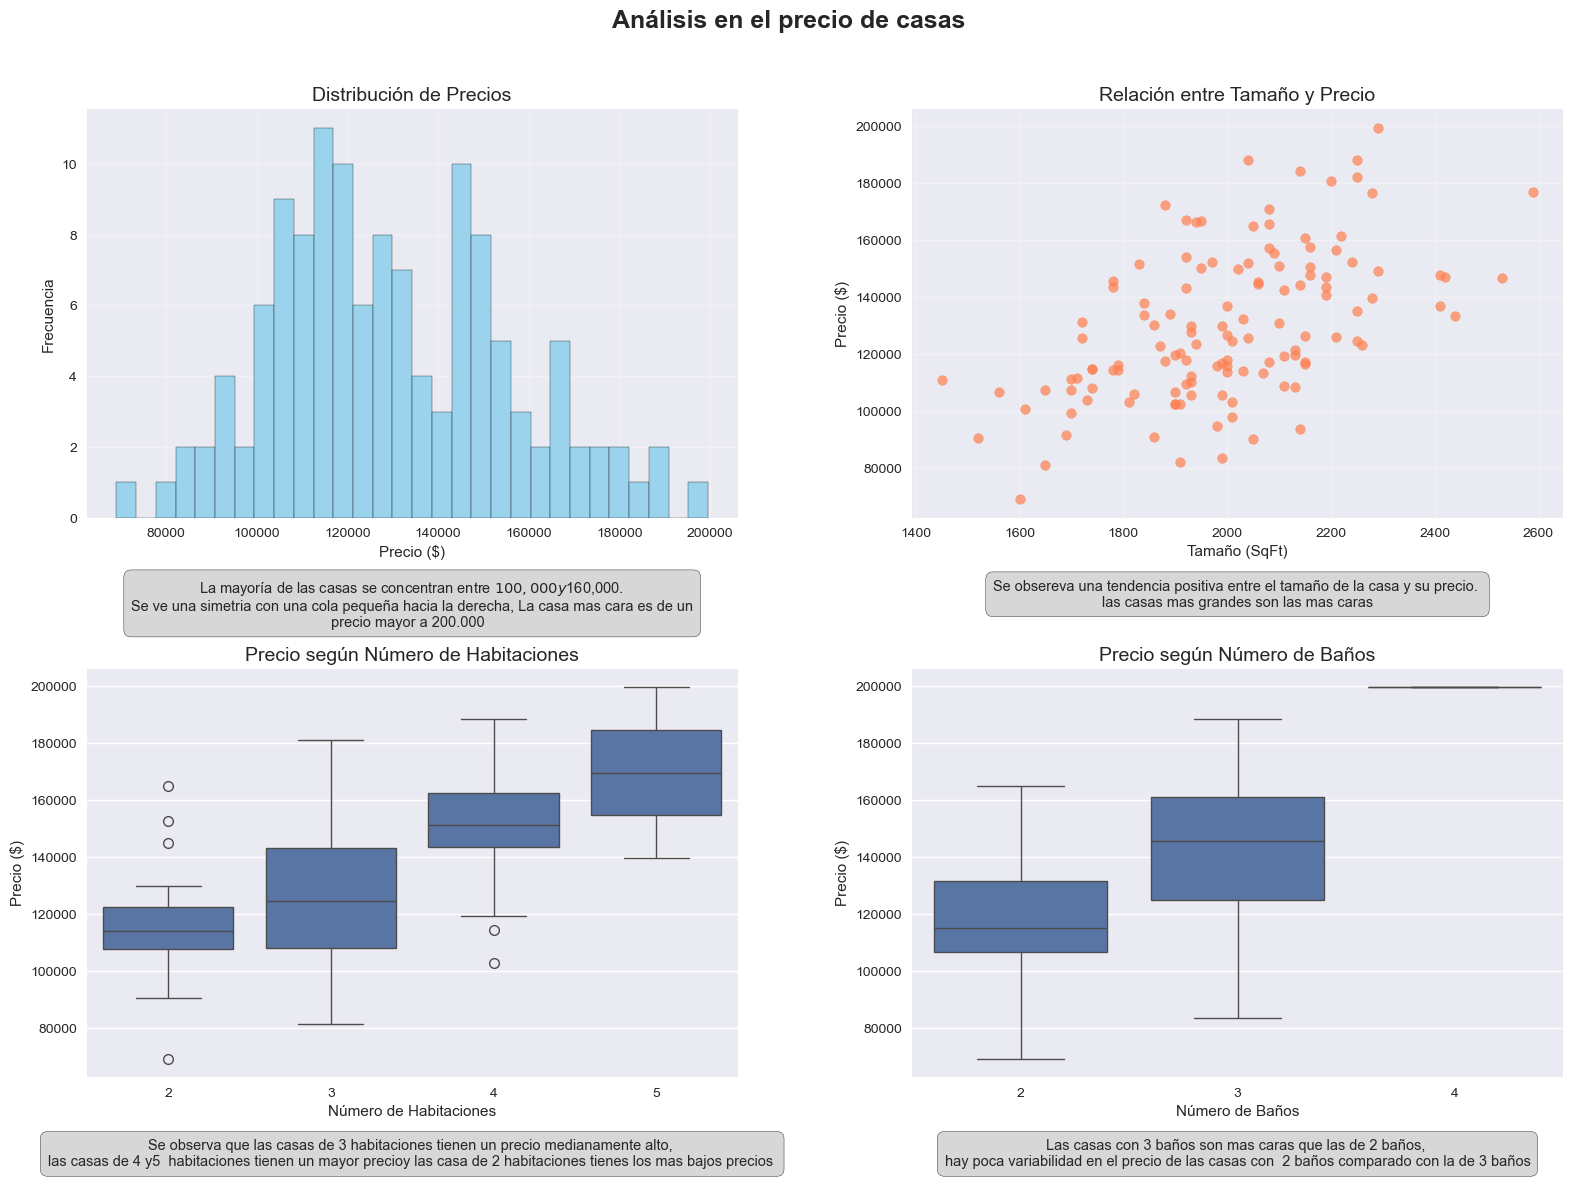

In [106]:
# graficos e interpretaciones


fig = plt.figure(figsize=(16, 12))
fig.suptitle('Análisis en el precio de casas', fontsize=18, fontweight='bold')

# grafico 1 : histograma de precios
ax1 = plt.subplot(2, 2, 1)
ax1.hist(df['Price'], bins=30, color='skyblue', edgecolor='black', alpha=0.8)
ax1.set_title('Distribución de Precios', fontsize=14)
ax1.set_xlabel('Precio ($)')
ax1.set_ylabel('Frecuencia')
ax1.grid(True, alpha=0.3)
# Interpretación dentro del gráfico 1
ax1.text(0.5, -0.15, 
         'La mayoría de las casas se concentran entre $100,000 y $160,000. \n' \
         'Se ve una simetria con una cola pequeña hacia la derecha, La casa mas cara es de un\n' \
         'precio mayor a 200.000  ',
         transform=ax1.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))
# grafico 2 : relacion entre tamaño y precio
ax2 = plt.subplot(2, 2, 2)
ax2.scatter(df['SqFt'], df['Price'], alpha=0.7, color='coral')
ax2.set_title('Relación entre Tamaño y Precio', fontsize=14)
ax2.set_xlabel('Tamaño (SqFt)')
ax2.set_ylabel('Precio ($)')
ax2.grid(True, alpha=0.3)
# Interpretación dentro del gráfico 2
ax2.text(0.5, -0.15, 
         'Se obsereva una tendencia positiva entre el tamaño de la casa y su precio. \n'
         'las casas mas grandes son las mas caras' 
         ,
         transform=ax2.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))

# grafico 3 : relacion entre numero de habitaciones y precio
ax3 = plt.subplot(2, 2, 3)
sns.boxplot(x='Bedrooms', y='Price', data=df, ax=ax3)
ax3.set_title('Precio según Número de Habitaciones', fontsize=14)
ax3.set_xlabel('Número de Habitaciones')
ax3.set_ylabel('Precio ($)')
# Interpretación dentro del gráfico 3
ax3.text(0.5, -0.15, 
         'Se observa que las casas de 3 habitaciones tienen un precio medianamente alto, \n'
         'las casas de 4 y5  habitaciones tienen un mayor precio'
         'y las casa de 2 habitaciones tienes los mas bajos precios ' 
         ,
         transform=ax3.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))

# grafico 4 : relacion entre numero de baños y precio
ax4 = plt.subplot(2, 2, 4)
sns.boxplot(x='Bathrooms', y='Price', data=df, ax=ax4)
ax4.set_title('Precio según Número de Baños', fontsize=14)
ax4.set_xlabel('Número de Baños')
ax4.set_ylabel('Precio ($)')

# Interpretación dentro del gráfico 3
ax4.text(0.5, -0.15, 
         'Las casas con 3 baños son mas caras que las de 2 baños, \n'
         'hay poca variabilidad en el precio de las casas con  2 baños comparado con la de 3 baños'
         ,
         transform=ax4.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

##### 3.- Preparación de datos: Divide los datos en un conjunto de entrenamiento (80%) y un conjunto de prueba (20%).


In [107]:

# separo el target y el feature
X = df.drop(columns=['Price'])
y = df['Price']

# cracion del entrenamiento y prueba
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)





##### 4.- Entrenamiento del modelo: Entrena un modelo de regresión lineal utilizando los datos de entrenamiento.


In [108]:

#  Crear modelo y entrenar
modelo = LinearRegression()
modelo.fit(X_train, y_train)
print('✅ Modelo entrenado')
print(f'Pendientes aprendidas: {modelo.coef_.round(2)}')
print(f'Intercepto:            {modelo.intercept_:,.2f}')

modelo

✅ Modelo entrenado
Pendientes aprendidas: [   34.82 11114.47 14156.07]
Intercepto:            -9,333.61


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##### 5.- Evaluación del modelo: Evalúa el modelo utilizando el conjunto de prueba. Calcula el error cuadrático medio (MSE) y el R-cuadrado (R²) del modelo.


In [109]:
#  Predecir con el set de test
y_pred = modelo.predict(X_test)

# Comparar real vs predicho (primeras 10)
comparacion = pd.DataFrame({
    'Real':     y_test.values[:10].round(0),
    'Predicho': y_pred[:10].round(0),
    'Error':    (y_test.values[:10] - y_pred[:10]).round(0)
})
comparacion

# metricas de evaluacion

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluacion del modelo .")
print(f'MSE: {mse:,.0f} ()')
print(f'R²: {r2:.4f} ({r2*100:.1f}%)')

Evaluacion del modelo .
MSE: 417,464,972 ()
R²: 0.2347 (23.5%)


##### 6.- Predicción: Usa el modelo entrenado para predecir el precio de una casa con las siguientes características:
#####    Tamaño: 2000 pies cuadrados
#####    Habitaciones: 3
#####    Baños: 2

In [110]:


new_price = pd.DataFrame(
    [{  'SqFt'       :  2000,
        'Bedrooms'   :  3,
        'Bathrooms'  :  2}]
)  # Ejemplo: casa de 2500 sqft, 4 habitaciones, 3 baños



prediccion = modelo.predict(new_price)[0]
print(f'Precio predicho:           ${prediccion:,.0f}')
print(f'Mediana real del dataset:  ${y.median():,.0f}')
print(f'¿Está dentro del rango razonable? {y.quantile(0.10) < prediccion < y.quantile(0.90)}')



Precio predicho:           $121,963
Mediana real del dataset:  $125,700
¿Está dentro del rango razonable? True
